#### Imports

In [1]:
# Imports
import os
import sys
import json
import pandas as pd

#### Path Configurations

In [2]:
# Get the absolute path to the 'project' directory
project_root = os.path.abspath(os.path.join('..', '..'))

# Add it to sys.path if it's not already there
if project_root not in sys.path:
    sys.path.append(project_root)

# Models Directory and Dataset Name
dataset = "football_players_detection_v11"
models_directory = os.path.join(project_root , "models" , "detection")

#### Utils Imports

In [3]:
from utils.analysis import plot_model_comparison_table

#### Gathering Additional Training Configs and Stats

In [4]:
data = []

for dirpath, dirnames, filenames in os.walk(models_directory):
   for filename in filenames:
      if filename.endswith(".json") and dataset in filename:
         json_file_path = os.path.join(dirpath, filename)
         with open(json_file_path) as f:
            model_detection_results = json.load(f)
            data.append({
                'model_name': model_detection_results['model_name'],
                #'epochs': model_detection_results['epochs_trained'],
                #'imgsz': model_detection_results['imgsz'],
                'overall_mAP50': model_detection_results['overall_metrics']['mAP50'],
                'overall_mAP50-95': model_detection_results['overall_metrics']['mAP50-95'],
                'ball_mAP50': model_detection_results['per_class_overall_metrics']['ball']['mAP50'],
                'ball_mAP50-95': model_detection_results['per_class_overall_metrics']['ball']['mAP50-95'],
            })

model_df = pd.DataFrame(data)

#### Best Model w/ Highest Overall mAP-50

In [5]:
overall_map50 = model_df.sort_values(by=['overall_mAP50'], ascending=False)
overall_map50.head(5)

,model_name,overall_mAP50,overall_mAP50-95,ball_mAP50,ball_mAP50-95
6,27-04-2026_17-06_yolo26x,0.9487,0.6807,0.8617,0.4689
0,27-04-2026_10-16_yolov8x,0.9079,0.6651,0.7400,0.3840
3,28-04-2026_13-38_rtdetr_v2_r50vd,0.8994,0.6643,0.7222,0.3188
2,28-04-2026_21-08_rtdetr_v2_r101vd,0.8952,0.5731,0.8029,0.3472
1,04-05-2026_08-51_rfdetr_m,0.8768,0.5693,0.5703,0.2353


#### Best Model w/ Highest Overall mAP-50-95

In [6]:
overall_map50_95 = model_df.sort_values(by=['overall_mAP50-95'], ascending=False)
overall_map50_95_head = overall_map50_95.head(5)
overall_map50_95_head

,model_name,overall_mAP50,overall_mAP50-95,ball_mAP50,ball_mAP50-95
6,27-04-2026_17-06_yolo26x,0.9487,0.6807,0.8617,0.4689
0,27-04-2026_10-16_yolov8x,0.9079,0.6651,0.7400,0.3840
3,28-04-2026_13-38_rtdetr_v2_r50vd,0.8994,0.6643,0.7222,0.3188
2,28-04-2026_21-08_rtdetr_v2_r101vd,0.8952,0.5731,0.8029,0.3472
4,29-04-2026_09-24_rfdetr_m,0.8620,0.5710,0.5472,0.2593


#### Best Model w/ Highest Ball mAP-50

In [7]:
ball_map50 = model_df.sort_values(by=['ball_mAP50'], ascending=False)
ball_map50.head(5)

,model_name,overall_mAP50,overall_mAP50-95,ball_mAP50,ball_mAP50-95
6,27-04-2026_17-06_yolo26x,0.9487,0.6807,0.8617,0.4689
2,28-04-2026_21-08_rtdetr_v2_r101vd,0.8952,0.5731,0.8029,0.3472
0,27-04-2026_10-16_yolov8x,0.9079,0.6651,0.7400,0.3840
3,28-04-2026_13-38_rtdetr_v2_r50vd,0.8994,0.6643,0.7222,0.3188
1,04-05-2026_08-51_rfdetr_m,0.8768,0.5693,0.5703,0.2353


#### Best Model w/ Highest Ball mAP-50-95

In [8]:
ball_map50_95 = model_df.sort_values(by=['ball_mAP50-95'], ascending=False)
ball_map50_95_head = ball_map50_95.head(5)
ball_map50_95_head

,model_name,overall_mAP50,overall_mAP50-95,ball_mAP50,ball_mAP50-95
6,27-04-2026_17-06_yolo26x,0.9487,0.6807,0.8617,0.4689
0,27-04-2026_10-16_yolov8x,0.9079,0.6651,0.7400,0.3840
2,28-04-2026_21-08_rtdetr_v2_r101vd,0.8952,0.5731,0.8029,0.3472
3,28-04-2026_13-38_rtdetr_v2_r50vd,0.8994,0.6643,0.7222,0.3188
4,29-04-2026_09-24_rfdetr_m,0.8620,0.5710,0.5472,0.2593


#### For any nice looking tables

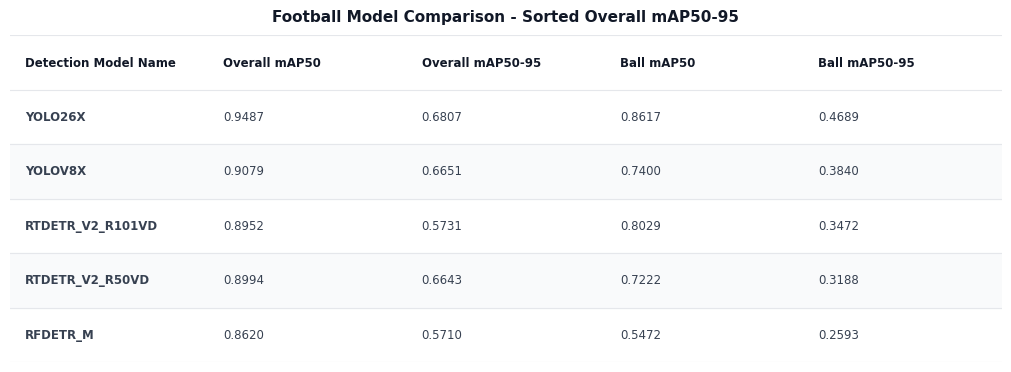

In [9]:
plot_model_comparison_table(ball_map50_95_head,"Football Model Comparison - Sorted Overall mAP50-95")